# 05 — Traditional ML: Logistic Regression and SVM from Scratch

This notebook implements two classical classifiers from scratch using NumPy only:
- **Logistic Regression** — trained via gradient descent with cross-entropy loss
- **Linear SVM** — trained via gradient descent with hinge loss

**Goal:** establish a performance baseline before moving to neural networks.
Images are flattened to 1D feature vectors (224×224×3 = 150,528 features), which discards all spatial structure — shapes, textures, edges. This is an intentional limitation of the approach, and the reason we expect modest accuracy compared to convolutional models in notebooks 06 and 07.

Results from this notebook serve as the comparison benchmark for all subsequent models.

Note: scikit-learn is used only for data utilities (splitting, metrics) — not for model implementation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Display settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

PROCESSED_IMAGES_DIR = Path("../data/processed/images")

## Image Loading and Preprocessing for Traditional ML

Full-resolution images (224×224×3 = 150,528 features) cannot be used directly —
the resulting feature matrix would require ~12 GB of RAM for the training set alone,
which exceeds available memory for traditional ML algorithms.

**Approach:**
- Resize to 32×32 pixels
- Convert to grayscale (1 channel) — colour information is less critical for
  traditional ML since spatial structure is already lost by flattening
- Flatten to 1D vector: 32×32 = 1,024 features per image
- Normalize pixel values to [0, 1] by dividing by 255

This reduces memory from ~12 GB to ~85 MB for the training set.

In [2]:
IMG_SIZE = 32  # 32x32 grayscale = 1,024 features per image

def load_split(split_name):
    X, y = [], []
    split_dir = PROCESSED_IMAGES_DIR / split_name
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        for img_path in class_dir.glob("*.jpg"):
            img = Image.open(img_path).convert("L").resize((IMG_SIZE, IMG_SIZE))
            X.append(np.array(img).flatten() / 255.0)
            y.append(class_dir.name)
    return np.array(X, dtype=np.float32), np.array(y)

print("Loading train...")
X_train, y_train = load_split("train")
print("Loading val...")
X_val,   y_val   = load_split("val")
print("Loading test...")
X_test,  y_test  = load_split("test")

le = LabelEncoder()
le.fit(y_train)
y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print(f"\nTrain: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")
print(f"Features per image: {X_train.shape[1]}")
print(f"Classes: {list(le.classes_)}")

Loading train...
Loading val...
Loading test...

Train: (20587, 1024)
Val:   (2571, 1024)
Test:  (2580, 1024)
Features per image: 1024
Classes: [np.str_('black_spot'), np.str_('downy_mildew'), np.str_('healthy_leaf'), np.str_('insect_damage'), np.str_('powdery_mildew'), np.str_('rose_mosaic'), np.str_('rose_rust')]


In [3]:
class LogisticRegression:

    def __init__(self, lr=0.1, n_epochs=100, batch_size=256):
        self.lr = lr
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.W = None
        self.b = None
        self.train_losses = []
        self.val_losses   = []

    def _softmax(self, z):
        z = z - z.max(axis=1, keepdims=True)  # numerical stability
        exp_z = np.exp(z)
        return exp_z / exp_z.sum(axis=1, keepdims=True)

    def _loss(self, X, y):
        probs = self._softmax(X @ self.W + self.b)
        correct = probs[np.arange(len(y)), y]
        return -np.mean(np.log(correct + 1e-9))

    def fit(self, X_train, y_train, X_val, y_val):
        n, n_features = X_train.shape
        n_classes = len(np.unique(y_train))

        self.W = np.zeros((n_features, n_classes))
        self.b = np.zeros(n_classes)

        for epoch in range(self.n_epochs):
            idx = np.random.permutation(n)
            X_s, y_s = X_train[idx], y_train[idx]

            for start in range(0, n, self.batch_size):
                Xb = X_s[start:start + self.batch_size]
                yb = y_s[start:start + self.batch_size]

                probs = self._softmax(Xb @ self.W + self.b)
                probs[np.arange(len(yb)), yb] -= 1
                probs /= len(yb)

                self.W -= self.lr * (Xb.T @ probs)
                self.b -= self.lr * probs.sum(axis=0)

            self.train_losses.append(self._loss(X_train, y_train))
            self.val_losses.append(self._loss(X_val, y_val))

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1:3d}/{self.n_epochs} "
                      f"— train loss: {self.train_losses[-1]:.4f} "
                      f"  val loss: {self.val_losses[-1]:.4f}")

    def predict(self, X):
        return np.argmax(self._softmax(X @ self.W + self.b), axis=1)


print("Training Logistic Regression...")
lr_model = LogisticRegression(lr=0.1, n_epochs=100, batch_size=256)
lr_model.fit(X_train, y_train_enc, X_val, y_val_enc)

Training Logistic Regression...
Epoch  10/100 — train loss: 5.4373   val loss: 5.4006
Epoch  20/100 — train loss: 5.7681   val loss: 5.7419
Epoch  30/100 — train loss: 3.9975   val loss: 3.8989
Epoch  40/100 — train loss: 3.8129   val loss: 3.8517
Epoch  50/100 — train loss: 3.8365   val loss: 3.9010
Epoch  60/100 — train loss: 4.0976   val loss: 4.1831
Epoch  70/100 — train loss: 4.6745   val loss: 4.6749
Epoch  80/100 — train loss: 2.3652   val loss: 2.3050
Epoch  90/100 — train loss: 6.3691   val loss: 6.3920
Epoch 100/100 — train loss: 2.4399   val loss: 2.5004


In [6]:
np.random.seed(42)
lr_model = LogisticRegression(lr=0.01, n_epochs=100, batch_size=256)
lr_model.fit(X_train, y_train_enc, X_val, y_val_enc)

Epoch  10/100 — train loss: 1.3500   val loss: 1.3332
Epoch  20/100 — train loss: 1.2941   val loss: 1.2766
Epoch  30/100 — train loss: 1.2554   val loss: 1.2390
Epoch  40/100 — train loss: 1.2228   val loss: 1.2079
Epoch  50/100 — train loss: 1.2111   val loss: 1.2009
Epoch  60/100 — train loss: 1.1951   val loss: 1.1851
Epoch  70/100 — train loss: 1.1930   val loss: 1.1807
Epoch  80/100 — train loss: 1.1671   val loss: 1.1560
Epoch  90/100 — train loss: 1.1535   val loss: 1.1455
Epoch 100/100 — train loss: 1.1480   val loss: 1.1382


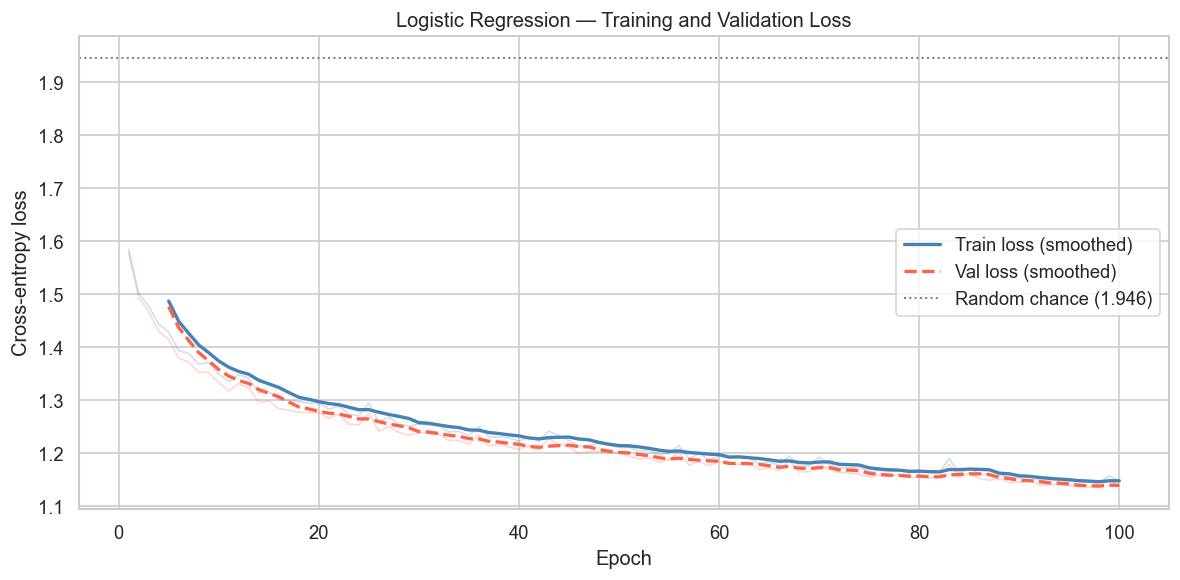

In [7]:
def smooth(values, window=5):
    return np.convolve(values, np.ones(window)/window, mode="valid")

fig, ax = plt.subplots(figsize=(10, 5))

epochs = range(1, len(lr_model.train_losses) + 1)
ax.plot(epochs, lr_model.train_losses, color="steelblue", alpha=0.25, linewidth=1)
ax.plot(epochs, lr_model.val_losses, color="tomato", alpha=0.25, linewidth=1)

w = 5
ax.plot(range(w, len(lr_model.train_losses) + 1), smooth(lr_model.train_losses, w),
        color="steelblue", linewidth=2, label="Train loss (smoothed)")
ax.plot(range(w, len(lr_model.val_losses) + 1), smooth(lr_model.val_losses, w),
        color="tomato", linewidth=2, linestyle="--", label="Val loss (smoothed)")

ax.axhline(y=1.946, color="gray", linestyle=":", linewidth=1.2,
           label="Random chance (1.946)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Logistic Regression — Training and Validation Loss")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
y_pred_train = lr_model.predict(X_train)
y_pred_val   = lr_model.predict(X_val)
y_pred_test  = lr_model.predict(X_test)

train_acc = np.mean(y_pred_train == y_train_enc)
val_acc   = np.mean(y_pred_val   == y_val_enc)
test_acc  = np.mean(y_pred_test  == y_test_enc)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Val   accuracy: {val_acc:.4f}")
print(f"Test  accuracy: {test_acc:.4f}")

print("\nClassification Report (Test set):")
print(classification_report(y_test_enc, y_pred_test,
                             target_names=le.classes_))

Train accuracy: 0.5649
Val   accuracy: 0.5850
Test  accuracy: 0.5558

Classification Report (Test set):
                precision    recall  f1-score   support

    black_spot       0.42      0.41      0.42       463
  downy_mildew       0.62      0.48      0.54       271
  healthy_leaf       0.49      0.76      0.60       818
 insect_damage       0.82      0.53      0.64       417
powdery_mildew       0.43      0.27      0.33       188
   rose_mosaic       0.20      0.01      0.02        98
     rose_rust       0.83      0.69      0.75       325

      accuracy                           0.56      2580
     macro avg       0.55      0.45      0.47      2580
  weighted avg       0.57      0.56      0.54      2580



## Logistic Regression — Evaluation Results

**Test accuracy: 55.6%** (random chance baseline: 14.3%)

The model learns a meaningful signal from flattened 32x32 grayscale pixels,
but performance is uneven across classes:

- **Best classes:** rose_rust (f1=0.75) and insect_damage (precision=0.82) —
  distinctive pixel patterns recognisable even at low resolution
- **Weakest class:** rose_mosaic (f1=0.02) — essentially not recognised.
  Caused by class imbalance (967 train samples) and similar pixel profile
  to rose_rust identified in EDA cell 4
- **healthy_leaf** is overpredicted (recall=0.76, precision=0.49) —
  direct effect of class imbalance (8,173 train samples)

These results confirm the structural limitation of flattened pixel features:
spatial information (shapes, textures, edges) is lost. This baseline will be
compared against SVM, NN (notebook 06), and CNN (notebook 07).

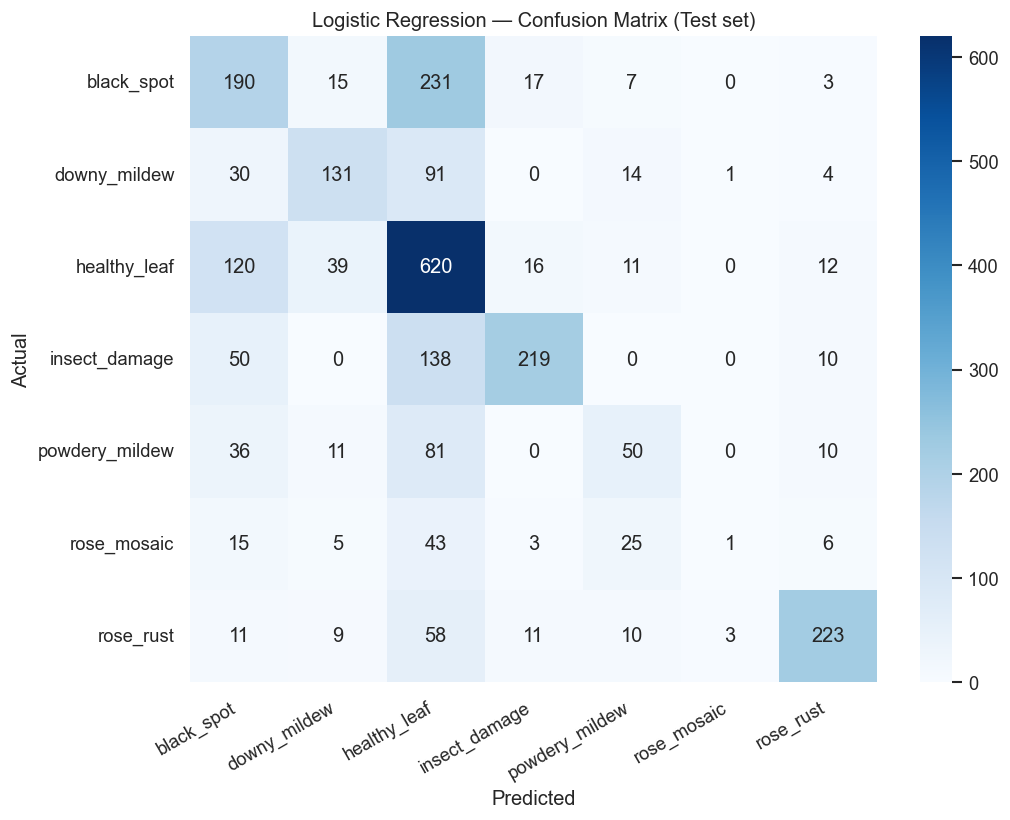

In [9]:
cm = confusion_matrix(y_test_enc, y_pred_test)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Logistic Regression — Confusion Matrix (Test set)")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()


## Logistic Regression — Confusion Matrix Analysis

**Dominant pattern: healthy_leaf bias**
The model classifies a large portion of every disease class as healthy_leaf:
- black_spot → healthy_leaf: 231 misclassifications (50% of all black_spot samples)
- insect_damage → healthy_leaf: 138 (33%)
- rose_mosaic → healthy_leaf: 43 (44%)

Likely cause: class imbalance (8,173 train samples) combined with loss of spatial information at 32x32 grayscale — disease symptoms are indistinguishable from healthy tissue
at this resolution without texture context.

**Best recognised classes:**
- healthy_leaf: 620/818 correct (75.8%) — dominant class, model biased toward it
- rose_rust: 223/325 correct (68.6%) — distinctive pixel pattern even at low resolution
- insect_damage: 219/417 correct (52.5%) — high brightness distinguishes it partially

**Worst recognised:**
- rose_mosaic: 1/98 correct (1%) — virtually ignored. Minority class with pixel
  profile similar to rose_rust and healthy tissue at 32x32
- powdery_mildew: 50/188 correct (26.6%)

**Conclusion:** the confusion matrix confirms that flattened grayscale pixels at 32x32 are insufficient for reliable disease classification. The model defaults to the majority
class and cannot separate visually similar diseases. CNN with spatial feature extraction is expected to improve results significantly.

In [11]:
class LinearSVM:

    def __init__(self, lr=0.01, n_epochs=100, batch_size=256, lambda_reg=0.001):
        self.lr         = lr
        self.n_epochs   = n_epochs
        self.batch_size = batch_size
        self.lambda_reg = lambda_reg
        self.W = None
        self.b = None
        self.train_losses = []
        self.val_losses   = []

    def _hinge_loss(self, X, y_binary, k):
        scores  = X @ self.W[:, k] + self.b[k]
        margins = 1 - y_binary * scores
        loss = np.maximum(0, margins).mean()
        reg = self.lambda_reg * np.sum(self.W[:, k] ** 2)
        return loss + reg
    
    def fit(self, X_train, y_train, X_val, y_val, n_classes):
        n, n_features = X_train.shape
        self.W = np.zeros((n_features, n_classes))
        self.b = np.zeros(n_classes)

        for epoch in range(self.n_epochs):
            idx = np.random.permutation(n)
            X_s, y_s = X_train[idx], y_train[idx]

            for start in range(0, n, self.batch_size):
                Xb = X_s[start:start + self.batch_size]
                yb = y_s[start:start + self.batch_size]
                nb = len(Xb)

                for k in range(n_classes):
                    y_binary = np.where(yb == k, 1, -1).astype(float)
                    scores = Xb @ self.W[:, k] + self.b[k]
                    mask = (1 - y_binary * scores) > 0

                    dW = 2 * self.lambda_reg * self.W[:, k]
                    db = 0.0
                    if mask.any():
                        dW -= (Xb[mask] * y_binary[mask, None]).mean(axis=0)
                        db -= y_binary[mask].mean()

                    self.W[:, k] -= self.lr * dW
                    self.b[k] -= self.lr * db

            train_loss = np.mean([
                self._hinge_loss(X_train, np.where(y_train == k, 1, -1).astype(float), k)
                for k in range(n_classes)
            ])
            val_loss = np.mean([
                self._hinge_loss(X_val, np.where(y_val == k, 1, -1).astype(float), k)
                for k in range(n_classes)
            ])
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1:3d}/{self.n_epochs} "
                      f"— train loss: {train_loss:.4f} "
                      f"  val loss: {val_loss:.4f}")

    def predict(self, X):
        return np.argmax(X @ self.W + self.b, axis=1)


np.random.seed(42)
svm_model = LinearSVM(lr=0.01, n_epochs=100, batch_size=256, lambda_reg=0.001)
svm_model.fit(X_train, y_train_enc, X_val, y_val_enc, n_classes=7)

Epoch  10/100 — train loss: 0.5371   val loss: 0.5391
Epoch  20/100 — train loss: 0.4402   val loss: 0.4377
Epoch  30/100 — train loss: 0.5413   val loss: 0.5437
Epoch  40/100 — train loss: 0.3671   val loss: 0.3642
Epoch  50/100 — train loss: 0.3680   val loss: 0.3664
Epoch  60/100 — train loss: 0.4636   val loss: 0.4680
Epoch  70/100 — train loss: 0.3323   val loss: 0.3272
Epoch  80/100 — train loss: 0.4257   val loss: 0.4289
Epoch  90/100 — train loss: 0.4760   val loss: 0.4801
Epoch 100/100 — train loss: 0.5182   val loss: 0.5244


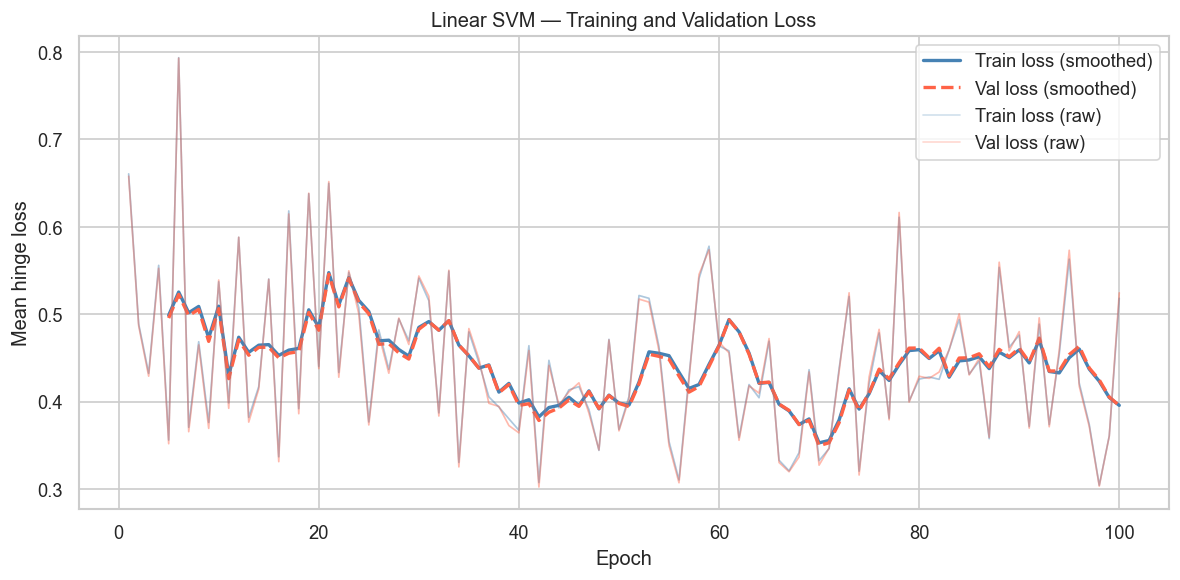

In [14]:
def smooth(values, window=5):
    return np.convolve(values, np.ones(window)/window, mode="valid")

fig, ax = plt.subplots(figsize=(10, 5))

epochs = range(1, len(svm_model.train_losses) + 1)
ax.plot(epochs, svm_model.train_losses, color="steelblue", alpha=0.25, linewidth=1)
ax.plot(epochs, svm_model.val_losses,   color="tomato",    alpha=0.25, linewidth=1)

w = 5
ax.plot(range(w, len(svm_model.train_losses) + 1), smooth(svm_model.train_losses, w),
        color="steelblue", linewidth=2, label="Train loss (smoothed)")
ax.plot(range(w, len(svm_model.val_losses) + 1), smooth(svm_model.val_losses, w),
        color="tomato", linewidth=2, linestyle="--", label="Val loss (smoothed)")
ax.plot(epochs, svm_model.train_losses, color="steelblue", alpha=0.25, linewidth=1,
        label="Train loss (raw)")
ax.plot(epochs, svm_model.val_losses,   color="tomato",    alpha=0.25, linewidth=1,
        label="Val loss (raw)")

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean hinge loss")
ax.set_title("Linear SVM — Training and Validation Loss")
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
np.random.seed(42)
svm_model = LinearSVM(lr=0.001, n_epochs=100, batch_size=256, lambda_reg=0.001)
svm_model.fit(X_train, y_train_enc, X_val, y_val_enc, n_classes=7)

Epoch  10/100 — train loss: 0.3080   val loss: 0.3075
Epoch  20/100 — train loss: 0.2928   val loss: 0.2920
Epoch  30/100 — train loss: 0.2835   val loss: 0.2821
Epoch  40/100 — train loss: 0.2752   val loss: 0.2736
Epoch  50/100 — train loss: 0.2689   val loss: 0.2670
Epoch  60/100 — train loss: 0.2646   val loss: 0.2621
Epoch  70/100 — train loss: 0.2608   val loss: 0.2580
Epoch  80/100 — train loss: 0.2574   val loss: 0.2549
Epoch  90/100 — train loss: 0.2535   val loss: 0.2509
Epoch 100/100 — train loss: 0.2535   val loss: 0.2508


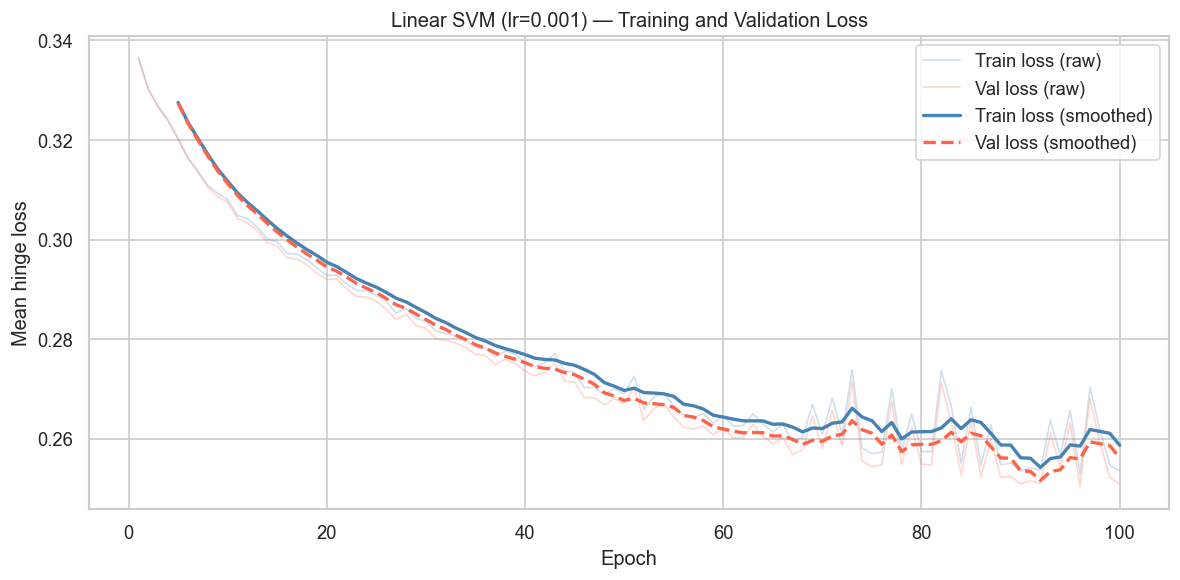

In [16]:
def smooth(values, window=5):
    return np.convolve(values, np.ones(window)/window, mode="valid")

fig, ax = plt.subplots(figsize=(10, 5))

epochs = range(1, len(svm_model.train_losses) + 1)
ax.plot(epochs, svm_model.train_losses, color="steelblue", alpha=0.25,
        linewidth=1, label="Train loss (raw)")
ax.plot(epochs, svm_model.val_losses,   color="tomato",    alpha=0.25,
        linewidth=1, label="Val loss (raw)")

w = 5
ax.plot(range(w, len(svm_model.train_losses) + 1), smooth(svm_model.train_losses, w),
        color="steelblue", linewidth=2, label="Train loss (smoothed)")
ax.plot(range(w, len(svm_model.val_losses) + 1), smooth(svm_model.val_losses, w),
        color="tomato", linewidth=2, linestyle="--", label="Val loss (smoothed)")

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean hinge loss")
ax.set_title("Linear SVM (lr=0.001) — Training and Validation Loss")
ax.legend()
plt.tight_layout()
plt.show()

## Linear SVM — Training Results (lr=0.001)

Training with the initial learning rate (lr=0.01) produced unstable oscillations —
identical symptom to Logistic Regression with lr=0.1. Reducing to lr=0.001 resolved
the instability.

With lr=0.001 the loss decreases smoothly from ~0.33 to ~0.26 over 100 epochs,
stabilising around epoch 60. Train and validation loss remain nearly identical
throughout — no overfitting observed.

Note: hinge loss (SVM) and cross-entropy loss (LR) operate on different scales
and cannot be compared directly. Model quality is compared via accuracy and
f1-score in the evaluation section below.

Train accuracy: 0.5185
Val   accuracy: 0.5340
Test  accuracy: 0.5112

Classification Report (Test set):
                precision    recall  f1-score   support

    black_spot       0.42      0.21      0.28       463
  downy_mildew       0.48      0.55      0.51       271
  healthy_leaf       0.49      0.69      0.57       818
 insect_damage       0.75      0.52      0.62       417
powdery_mildew       0.46      0.17      0.25       188
   rose_mosaic       0.08      0.14      0.10        98
     rose_rust       0.71      0.74      0.73       325

      accuracy                           0.51      2580
     macro avg       0.48      0.43      0.44      2580
  weighted avg       0.53      0.51      0.50      2580



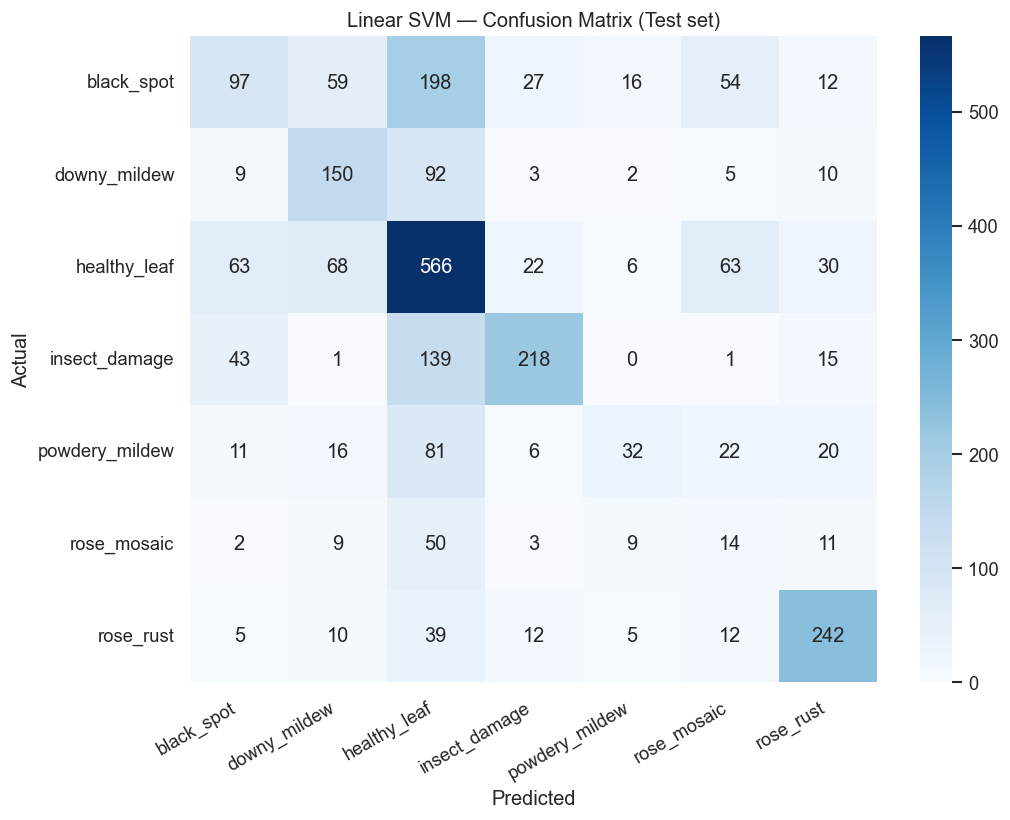

In [17]:
y_pred_train_svm = svm_model.predict(X_train)
y_pred_val_svm   = svm_model.predict(X_val)
y_pred_test_svm  = svm_model.predict(X_test)

train_acc = np.mean(y_pred_train_svm == y_train_enc)
val_acc   = np.mean(y_pred_val_svm   == y_val_enc)
test_acc  = np.mean(y_pred_test_svm  == y_test_enc)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Val   accuracy: {val_acc:.4f}")
print(f"Test  accuracy: {test_acc:.4f}")

print("\nClassification Report (Test set):")
print(classification_report(y_test_enc, y_pred_test_svm,
                             target_names=le.classes_))

cm_svm = confusion_matrix(y_test_enc, y_pred_test_svm)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Linear SVM — Confusion Matrix (Test set)")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## Linear SVM — Evaluation

After training, we evaluate the model on the held-out test set to measure how well
it generalises to unseen data. Training accuracy alone is not a reliable indicator —
a model can memorise the training data without learning meaningful patterns.

We report:
- **Accuracy** — overall percentage of correct predictions
- **Classification report** — precision, recall and f1-score per class,
  which reveals how performance varies across the 7 disease classes
- **Confusion matrix** — shows which classes are confused with each other

Results will be compared directly against Logistic Regression (test accuracy: 55.6%)
to determine whether SVM offers any advantage on this feature representation.

## LR vs Linear SVM — Comparison

| Metric | Logistic Regression | Linear SVM |
|---|---|---|
| Test accuracy | **55.6%** | 51.1% |
| Macro avg f1 | **0.47** | 0.44 |
| Weighted avg f1 | **0.54** | 0.50 |

**Logistic Regression wins overall** — 4.5 percentage points higher test accuracy.

**Per-class comparison:**
- LR outperforms SVM on 5 of 7 classes: black_spot (0.42 vs 0.28),
  downy_mildew (0.54 vs 0.51), healthy_leaf (0.60 vs 0.57),
  powdery_mildew (0.33 vs 0.25), rose_rust (0.75 vs 0.73)
- SVM shows marginal improvement only on rose_mosaic (f1=0.10 vs 0.02) —
  the margin-based objective may handle the minority class slightly better

**Both models share the same structural limitations:**
- healthy_leaf bias persists in both (dominant class, most misclassification target)
- rose_mosaic remains poorly recognised in both (minority class, limited signal at 32x32)
- Spatial information is lost by flattening — neither model can capture texture or shape

**Conclusion:** on this feature representation (32x32 grayscale, flattened pixels),
Logistic Regression performs better than Linear SVM. Neither model is expected to be
the final solution — both serve as the baseline for comparison with neural network
approaches in notebooks 06 and 07.

# Notebook 05 — Conclusions and Next Steps

## Summary

Two linear classifiers were implemented from scratch using NumPy and evaluated
on 32x32 grayscale flattened image features (1,024 features per image):

| Model | Test Accuracy | Macro F1 |
|---|---|---|
| Logistic Regression (lr=0.01) | 55.6% | 0.47 |
| Linear SVM (lr=0.001) | 51.1% | 0.44 |
| Random chance baseline | 14.3% | — |

Both models significantly outperform random chance, confirming that even minimal
pixel-level features carry some discriminative signal.

## Key Findings

- Logistic Regression outperforms Linear SVM on this feature representation
- Both models suffer from healthy_leaf bias caused by class imbalance
- rose_mosaic is the hardest class for both models — minority class with weak
  pixel signal at 32x32 resolution
- rose_rust and insect_damage are the best recognised classes in both models
- Flattening images to 1D vectors discards all spatial structure — shapes,
  textures and edges are not captured by either model

## Limitations

Results reflect the constraints of the chosen feature representation, not
the inherent difficulty of the classification task. A model with access to
spatial features is expected to perform substantially better.

## Next Steps

- Notebook 06: Neural Network from scratch (NumPy) — introduces non-linearity
  and hidden layer representations
- Notebook 07: CNN with transfer learning — spatial feature extraction via
  convolutions; expected to address the core limitations identified here
- All baseline results from this notebook will be used as the comparison
  benchmark in notebook 09 (MLflow experiment tracking)